# Retail Data Wrangling and Analytics

In [1]:
# Import modules 
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Load Data from PSQL into DataFrame

**Setup Docker Containers**

![](https://i.imgur.com/VQrBVBk.jpg)

```
#make sure you have both Jupyter and PSQL docker container running
docker ps

#Attach a bridge network to both containers so they can communicate with each other
docker network create jarvis-net
#this command works on running containers
docker network connect jarvis-net jarvis-jupyter
docker network connect jarvis-net jarvis-psql

#verify both containers are attached to the jarvis-net
docker network inspect trading-net

#Note: instead of using `localhost`, you should use container names as hostnames.
```

**Data Preperation**

- Use [pandas.read_sql](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_sql.html) api to load the PSQL retail table into a Pandas DataFrame

![](https://i.imgur.com/AmkAP63.jpg)

- Get familair with the transaction date with `df.head()`, `df.sample(10)`, `df.info()`, `df.describe()`, etc..



In [2]:
#install psql "driver"
!pip3 install psycopg2-binary

In [3]:
import psycopg2
conn=conn = psycopg2.connect(
    database="postgres", user='postgres', password='rocky1234', host='jrvs-psql', port='5432'
)

engine_string = ""
engine = ""
retail_df = pd.read_sql("SELECT * FROM public.retail", conn)
retail_df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536988,22910,PAPER CHAIN KIT VINTAGE CHRISTMAS,2,2010-12-03 15:05:00,2.95,17238.0,United Kingdom
1,536988,22966,GINGERBREAD MAN COOKIE CUTTER,4,2010-12-03 15:05:00,1.25,17238.0,United Kingdom
2,536988,84380,SET OF 3 BUTTERFLY COOKIE CUTTERS,2,2010-12-03 15:05:00,1.25,17238.0,United Kingdom
3,536988,21479,WHITE SKULL HOT WATER BOTTLE,1,2010-12-03 15:05:00,3.75,17238.0,United Kingdom
4,536988,22694,WICKER STAR,1,2010-12-03 15:05:00,2.10,17238.0,United Kingdom


In [4]:
retail_df.info()
retail_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice_no    1067371 non-null  object        
 1   stock_code    1067371 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1067371 non-null  int64         
 4   invoice_date  1067371 non-null  datetime64[ns]
 5   unit_price    1067371 non-null  float64       
 6   customer_id   824364 non-null   float64       
 7   country       1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


,quantity,unit_price,customer_id
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359440e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


# Load CSV into Dataframe
Alternatively, the LGS IT team also dumped the transactional data into a [CSV file](https://raw.githubusercontent.com/jarviscanada/jarvis_data_eng_demo/feature/data/python_data_wrangling/data/online_retail_II.csv). However, the CSV header (column names) doesn't follow the snakecase or camelcase naming convention (e.g. `Customer ID` instead of `customer_id` or `CustomerID`). As a result, you will need to use Pandas to clean up the data before doing any analytics. In addition, unlike the PSQL scheme, CSV files do not have data types associated. Therefore, you will need to cast/convert certain columns into correct data types (e.g. DateTime, numbers, etc..)

**Data Preperation**

- Read the `data/online_retail_II.csv` file into a DataFrame
- Rename all columns to upper camelcase or snakecase
- Convert/cast all columns to the appropriate data types (e.g. datetime)

In [5]:
retail_df = pd.read_csv("https://raw.githubusercontent.com/jarviscanada/jarvis_data_eng_demo/feature/data/python_data_wrangling/data/online_retail_II.csv")
retail_df.head()
retail_df=retail_df.rename(columns={'Invoice' : 'invoice', 'StockCode' : 'stock_code', 'Description' : 'description', 'Quantity' : 'quantity', 'InvoiceDate' : 'invoice_date', 'Price' : 'price' , 'Customer ID' : 'customer_id' , 'Country' : 'country'})
retail_df.head()

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Total Invoice Amount Distribution

The maximum is : 168469.593820572. The minimum is : -168469.593820572. The median is : 196.344997406006. The mean is : 359.6488864318629


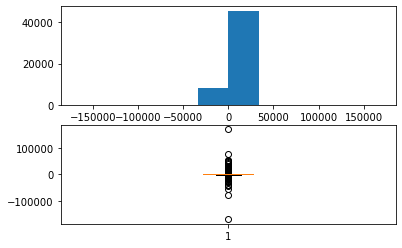

In [6]:
retail_invoice = pd.read_sql("SELECT sum(unit_price*quantity) from public.retail group by invoice_no", conn)
retail_invoice.head()
fig, ax = plt.subplots(2)

ax[0].hist(retail_invoice)
ax[1].boxplot(retail_invoice)
print("The maximum is : "+str(retail_invoice["sum"].max())+". The minimum is : "+str(retail_invoice["sum"].min())+". The median is : "+str(retail_invoice["sum"].median())+". The mean is : "+str(retail_invoice["sum"].mean()))

The maximum is : 593.999977111816. The minimum is : -168469.593820572. The median is : 141.899997711182. The mean is : 136.97756753209575


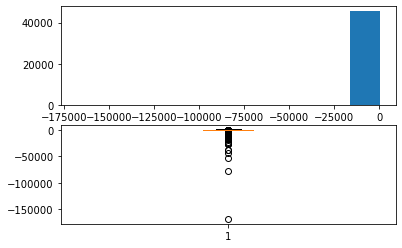

In [7]:
retail_invoice = pd.read_sql("SELECT sum(unit_price*quantity) from public.retail group by invoice_no", conn)
retail_invoice.head()
retail_invoice=retail_invoice.loc[retail_invoice["sum"]<retail_invoice.quantile(0.85)["sum"]]
fig, ax = plt.subplots(2)

ax[0].hist(retail_invoice)
ax[1].boxplot(retail_invoice)
print("The maximum is : "+str(retail_invoice["sum"].max())+". The minimum is : "+str(retail_invoice["sum"].min())+". The median is : "+str(retail_invoice["sum"].median())+". The mean is : "+str(retail_invoice["sum"].mean()))


# Monthly Placed and Canceled Orders

<AxesSubplot:xlabel='month'>

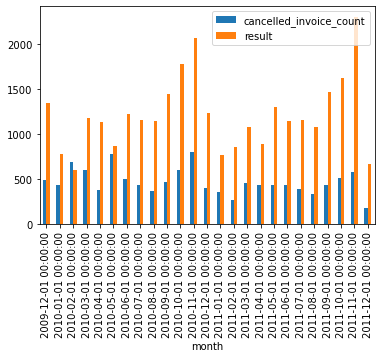

In [8]:
retail_monthly_cancelled=pd.read_sql("select DATE_TRUNC('month', invoice_date) AS month, COUNT(DISTINCT invoice_no) AS cancelled_invoice_count from public.retail where quantity<0 group by month", conn)
retail_monthly_cancelled.head()
retail_monthly_non_cancelled = pd.read_sql("SELECT DATE_TRUNC('month', invoice_date) AS month, COUNT(DISTINCT invoice_no) - 2 * COUNT(DISTINCT CASE WHEN quantity < 0 THEN invoice_no END) AS result FROM public.retail GROUP BY DATE_TRUNC('month', invoice_date) ORDER BY month", conn)
retail_monthly_non_cancelled.head()
df=pd.concat([retail_monthly_cancelled, retail_monthly_non_cancelled['result']], axis=1)
df.plot(x='month', y=['cancelled_invoice_count','result'], kind='bar')

# Monthly Sales

<AxesSubplot:xlabel='month'>

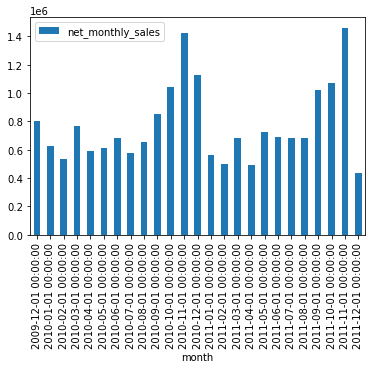

In [9]:
retail_monthly_sales=pd.read_sql("SELECT DATE_TRUNC('month', invoice_date) AS month, SUM(quantity * unit_price) AS net_monthly_sales FROM public.retail GROUP BY DATE_TRUNC('month', invoice_date) ORDER BY month", conn)
retail_monthly_sales.plot(x='month', y='net_monthly_sales', kind='bar')

# Monthly Sales Growth


<AxesSubplot:xlabel='month'>

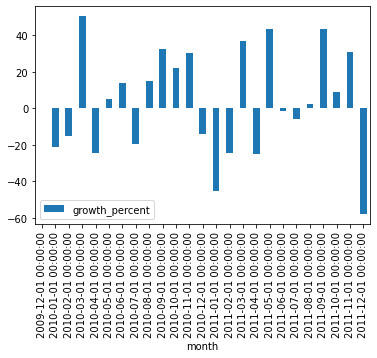

In [10]:
retail_monthly_sales_growth=pd.read_sql("WITH monthly_sales AS (SELECT DATE_TRUNC('month', invoice_date) AS month, SUM(quantity * unit_price) AS sales FROM public.retail WHERE quantity > 0 GROUP BY DATE_TRUNC('month', invoice_date)) SELECT month, sales, LAG(sales) OVER (ORDER BY month) AS prev_month_sales, ((sales - LAG(sales) OVER (ORDER BY month)) / LAG(sales) OVER (ORDER BY month)) * 100 AS growth_percent FROM monthly_sales ORDER BY month", conn)
retail_monthly_sales_growth.plot(x='month', y='growth_percent', kind='bar')

# Monthly Active Users

<AxesSubplot:xlabel='month'>

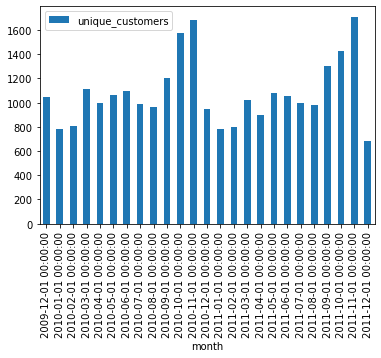

In [11]:
retail_monthly_active=pd.read_sql("SELECT DATE_TRUNC('month', invoice_date) AS month, COUNT(DISTINCT customer_id) AS unique_customers FROM public.retail GROUP BY DATE_TRUNC('month', invoice_date) ORDER BY month", conn)
retail_monthly_active.plot(x='month', y='unique_customers', kind='bar')

# New and Existing Users



<AxesSubplot:xlabel='month'>

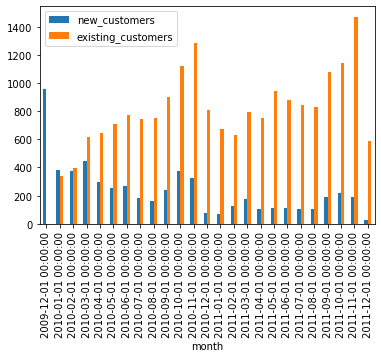

In [12]:
new_exit_users=pd.read_sql("WITH customer_first_purchase AS (SELECT customer_id, MIN(DATE_TRUNC('month', invoice_date)) AS first_purchase_month FROM public.retail WHERE quantity > 0 GROUP BY customer_id), monthly_customers AS (SELECT DATE_TRUNC('month', invoice_date) AS month, customer_id FROM public.retail WHERE quantity > 0 GROUP BY DATE_TRUNC('month', invoice_date), customer_id) SELECT mc.month, COUNT(DISTINCT mc.customer_id) AS total_customers, COUNT(DISTINCT CASE WHEN mc.month = cfp.first_purchase_month THEN mc.customer_id END) AS new_customers, COUNT(DISTINCT CASE WHEN mc.month > cfp.first_purchase_month THEN mc.customer_id END) AS existing_customers FROM monthly_customers mc JOIN customer_first_purchase cfp ON mc.customer_id = cfp.customer_id GROUP BY mc.month ORDER BY mc.month", conn)
new_exit_users.plot(x='month', y=['new_customers', 'existing_customers'], kind='bar')

## Finding RFM

RFM is a method used for analyzing customer value. It is commonly used in database marketing and direct marketing and has received particular attention in the retail and professional services industries. ([wikipedia](https://en.wikipedia.org/wiki/RFM_(market_research)))

Optional Reading: [Making Your Database Pay Off Using Recency Frequency and Monetary Analysis](http://www.dbmarketing.com/2010/03/making-your-database-pay-off-using-recency-frequency-and-monetary-analysis/)


RFM stands for three dimensions:

- Recency – How recently did the customer purchase?

- Frequency – How often do they purchase?

- Monetary Value – How much do they spend?

Note: To simplify the problem, let's keep all placed and canceled orders.


**Sample RFM table**

![](https://i.imgur.com/sXFIg6u.jpg)

In [13]:
rfm_table=pd.read_sql("WITH rfm AS (SELECT customer_id, DATE_PART('day', (SELECT MAX(invoice_date) FROM public.retail) - MAX(invoice_date)) AS recency, COUNT(DISTINCT invoice_no) AS frequency, SUM(quantity * unit_price) AS monetary FROM public.retail WHERE quantity > 0 GROUP BY customer_id) SELECT customer_id, recency, frequency, monetary, NTILE(4) OVER (ORDER BY recency DESC) AS r_score, NTILE(4) OVER (ORDER BY frequency) AS f_score, NTILE(4) OVER (ORDER BY monetary) AS m_score FROM rfm ORDER BY recency", conn)
rfm_table.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score
0,14796.0,0.0,27,10889.639891,4,4,4
1,15910.0,0.0,15,2681.799995,4,4,4
2,17668.0,0.0,2,347.749997,4,2,1
3,13013.0,0.0,29,12625.769904,4,4,4
4,13318.0,0.0,3,640.759997,4,3,2


# RFM Segmentation

---
**Please remove this insturction cell after you are done with coding**
RFM segmentation categorizes your customers into different segments, according to their interactions with your website, which will allow you to subsequently approach these groups in the most effective way. In this article, we will show you how to make an RFM segmentation based on an RFM score combining all three RFM parameters together and allowing you to divide your customers into 11 different segments. 

- [RFM Segmentation business cases](https://docs.exponea.com/docs/rfm-segmentation-business-use)

- [RFM Segmentation Guide](https://docs.exponea.com/docs/rfm-segmentation-business-use)

As you can see, computing RFM segmentation requires extensive domain knowledge in marketing which is out of the scope in this project. In practice, you will work with BA/DA to figure out how to compute RFM segments. To simplify this project, a [sample RFM segmentation Notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) is provided. You are responsible to understand everything from that Notebook and then integrate it into yours. 

- Download the [sample notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) and import to your Jupyter Notebook or VSCode
- Run the notebook and understand all cells
- Read the remark section at the end of the notebook. You will need this information when writing the README file
- Integrate the RFM segmentation calculation into your notebook

---

In [29]:
today = pd.datetime(2012,1,1) 
retail_df['invoice_date'] = pd.to_datetime(retail_df['invoice_date'])
retail_df['total_price'] = retail_df['price']*retail_df['quantity']
df_x = retail_df.groupby('customer_id').agg({'total_price': lambda x: x.sum(), #monetary value
                                        'invoice_date': lambda x: (today - x.max()).days}) #recency value


df_y = retail_df.groupby(['customer_id','invoice']).agg({'total_price': lambda x: x.sum()})
df_z = df_y.groupby('customer_id').agg({'total_price': lambda x: len(x)}) 

rfm_table= pd.merge(df_x,df_z, on='customer_id')

rfm_table.rename(columns= {'invoice_date': 'recency',
                          'total_price_y': 'frequency',
                          'total_price_x': 'monetary'}, inplace= True)

<ipython-input-29-0064f4f2d42a>:1: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  today = pd.datetime(2012,1,1)


In [30]:
rfm_table.head()

,monetary,recency,frequency
customer_id,,,
12346.0,-64.68,347,17.0
12347.0,5633.32,24,8.0
12348.0,2019.40,97,5.0
12349.0,4404.54,40,5.0
12350.0,334.40,332,1.0


In [31]:
rfm_table['recency_score'] = pd.qcut(rfm_table['recency'],5,labels=[5,4,3,2,1])
rfm_table['frequency_score'] = pd.qcut(rfm_table['frequency'].rank(method="first"),5,labels=[1,2,3,4,5])
rfm_table['monetary_score'] = pd.qcut(rfm_table['monetary'],5,labels=[1,2,3,4,5])

In [33]:
rfm_table.head()

,monetary,recency,frequency,recency_score,frequency_score,monetary_score
customer_id,,,,,,
12346.0,-64.68,347,17.0,2,5,1
12347.0,5633.32,24,8.0,5,4,5
12348.0,2019.40,97,5.0,3,3,4
12349.0,4404.54,40,5.0,5,3,5
12350.0,334.40,332,1.0,2,1,2


In [34]:
rfm_table['recency_score'] = pd.qcut(rfm_table['recency'],5,labels=[5,4,3,2,1])
rfm_table['frequency_score'] = pd.qcut(rfm_table['frequency'].rank(method="first"),5,labels=[1,2,3,4,5])
rfm_table['monetary_score'] = pd.qcut(rfm_table['monetary'],5,labels=[1,2,3,4,5])

In [35]:


rfm_table.head()



,monetary,recency,frequency,recency_score,frequency_score,monetary_score
customer_id,,,,,,
12346.0,-64.68,347,17.0,2,5,1
12347.0,5633.32,24,8.0,5,4,5
12348.0,2019.40,97,5.0,3,3,4
12349.0,4404.54,40,5.0,5,3,5
12350.0,334.40,332,1.0,2,1,2


In [36]:
(rfm_table['recency_score'].astype(str) + 
 rfm_table['frequency_score'].astype(str) + 
 rfm_table['monetary_score'].astype(str)).head()

customer_id
12346.0    251
12347.0    545
12348.0    334
12349.0    535
12350.0    212
dtype: object

In [37]:
rfm_table["RFM_SCORE"] = rfm_table['recency_score'].astype(str) + rfm_table['frequency_score'].astype(str) + rfm_table['monetary_score'].astype(str)

In [38]:


rfm_table.head()



,monetary,recency,frequency,recency_score,frequency_score,monetary_score,RFM_SCORE
customer_id,,,,,,,
12346.0,-64.68,347,17.0,2,5,1,251
12347.0,5633.32,24,8.0,5,4,5,545
12348.0,2019.40,97,5.0,3,3,4,334
12349.0,4404.54,40,5.0,5,3,5,535
12350.0,334.40,332,1.0,2,1,2,212


In [39]:
rfm_table.describe().T

,count,mean,std,min,25%,50%,75%,max
monetary,5942.0,2801.799459,13973.922553,-25111.09,325.0975,843.97,2182.005,598215.22
recency,5942.0,224.457085,211.881245,22.00,46.0000,117.50,403.000,760.00
frequency,5942.0,7.552339,15.972262,1.00,2.0000,4.00,8.000,510.00


In [40]:
rfm_table[rfm_table["RFM_SCORE"] == "555"].head()

,monetary,recency,frequency,recency_score,frequency_score,monetary_score,RFM_SCORE
customer_id,,,,,,,
12359.0,8714.89,29,14.0,5,5,5,555
12362.0,5284.58,25,14.0,5,5,5,555
12395.0,5046.92,37,18.0,5,5,5,555
12417.0,6708.21,25,27.0,5,5,5,555
12433.0,20428.86,22,11.0,5,5,5,555


In [41]:

rfm_table[rfm_table["RFM_SCORE"] == "111"].head()

,monetary,recency,frequency,recency_score,frequency_score,monetary_score,RFM_SCORE
customer_id,,,,,,,
12382.0,-18.38,704,1.0,1,1,1,111
12387.0,143.94,437,1.0,1,1,1,111
12392.0,234.75,613,1.0,1,1,1,111
12400.0,205.25,436,1.0,1,1,1,111
12404.0,63.24,704,1.0,1,1,1,111


In [42]:
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Lose',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

In [44]:
rfm_table['segment'] = rfm_table['recency_score'].astype(str) + rfm_table['frequency_score'].astype(str)
rfm_table['segment'] = rfm_table['segment'].replace(seg_map, regex=True)

In [45]:


rfm_table.head()



,monetary,recency,frequency,recency_score,frequency_score,monetary_score,RFM_SCORE,Segment,segment
customer_id,,,,,,,,,
12346.0,-64.68,347,17.0,2,5,1,251,25,Can't Lose
12347.0,5633.32,24,8.0,5,4,5,545,54,Champions
12348.0,2019.40,97,5.0,3,3,4,334,33,Need Attention
12349.0,4404.54,40,5.0,5,3,5,535,53,Potential Loyalists
12350.0,334.40,332,1.0,2,1,2,212,21,Hibernating


In [ ]:
rfm_table[["Segment", "Recency","Frequency","Monetary"]].groupby("Segment").agg(["mean","count"])